---

**Kaggle Competition Deadline:** Friday, 5 June 2026 at 3:00 PM (Week 13)  
**Assignment Due Date (iLearn):** Friday, 5 June 2026 at 11:59 PM (Week 13)  
**Total Marks:** 30  

**Overview**  
In this group assignment, you will form a team of three students and participate in a forecasting competition on Kaggle.

---
### General Instructions

- Each team member must create a Kaggle account and join the competition using the link:  
  https://www.kaggle.com/t/554f205a43a94920943d5227ae9dcbdb  

- Form a team of three students:  
  Choose a team leader who will create the team and invite the other members  
  The team name must begin with the unit code  

- All team members are expected to contribute to all tasks.  
  Each member must take primary responsibility for one of the three tasks.

- Your predictions must be generated using models developed in this assignment.  
  **A mark of zero will be awarded if your submitted forecasts cannot be reproduced from your code.**

- All results must be clearly presented and directly verifiable from your outputs and explanations.

- All written answers must be written in clear and complete sentences, supported by relevant tables, summary statistics, and visualisations where appropriate.  


<hr style="width:20%;margin-left:0;"> 

### Marks

- **Total Marks:** 30 (across 3 tasks)
    
- **Individual Mark Allocation:**  
  Each student’s mark is calculated as:  
      **50% × overall group assignment mark**  
      **50% × mark for the task they are responsible for**

<hr style="width:20%;margin-left:0;"> 

### Assignment Submission

1. **Kaggle Submission:**  
   - Submit your team’s forecasts on Kaggle to be ranked on the leaderboard  
2. **iLearn Submission (team leader only):**  
   - Submit the assignment as a Jupyter notebook, renamed to your **Kaggle team name**  
   - The notebook must include:
     - Names and student ID numbers of all team members  
     - Your Kaggle team name  
   - Submit **one 15-minute video presentation** of your work  
     - A penalty of **5 marks will be deducted per task** if a video presentation is not provided  

---
---

### <span style="background-color: yellow;">Fill out the following information

- Team Name on Kaggle: `BUSA3020 HighDistinctionTeam`
- Team Leader and Team Member 1: `Venantius Devon Istanto`
- Team Member 2: `Chi Cong Nguyen`
- Team Member 3: `Ngoc Tram Vu`

---
---

## Task 1: Problem Description and Exploratory Data Analysis (EDA)  

**Total Marks: 10**

- Based on the Competition Overview, datasets, and additional information provided on Kaggle, along with insights gained from your own research (including relevant academic sources such as Google Scholar), answer the following questions.  
- Do not discuss any predictive models in this task.


---

Student in charge of this task: `Venantius Devon Istanto`


<hr style="width:25%;margin-left:0;">    

#### 1. Forecasting Problem (2 marks)  
In approximately **300 words**, explain what we are trying to predict and how this problem can be applied in a real-world context.  
Discuss who may benefit from these predictions and how they might use them.


The objective of this competition is to predict the **daily price** of Airbnb listings in **Brisbane, Australia** using information about each property, host, availability, location and listing characteristics. Kaggle states that the competition aims to predict Airbnb listing prices in Brisbane, while the submission file must contain two columns, **ID** and **price**.

In practice, this is a **supervised regression** problem. We observe many listings for which the price is known in the training set, then use patterns in those data to estimate prices for listings in the test set. A reliable pricing model is valuable because Airbnb prices are influenced by many factors at the same time, such as room type, location, number of guests accommodated, reviews, host characteristics and property amenities. The relationship between these variables and price is unlikely to be perfectly linear, so data-driven forecasting can support better decisions than relying only on intuition.

These predictions have several real-world uses. **Hosts** can use them to benchmark their properties against similar listings and set prices more competitively. **Property managers** can use predicted prices to support revenue planning, dynamic pricing and portfolio management. **Travellers** may indirectly benefit when prices become more consistent with listing quality and location. **Airbnb itself** or market analysts could also use such models to understand which property characteristics are associated with higher prices and to monitor local market conditions.

More broadly, the problem is an example of **property price prediction in the short-term rental market**. Unlike long-term housing valuation, Airbnb pricing reflects both property features and platform-specific signals such as reviews, host responsiveness and booking availability. This makes the problem commercially relevant, because accurate forecasts can improve pricing efficiency, increase occupancy and help market participants make more informed decisions.


<hr style="width:25%;margin-left:0;">   

#### 2. Evaluation Criteria (2 marks)  
Describe the evaluation metric used in this competition to assess forecasting performance.  
Provide the equation and discuss its advantages and potential limitations.

The evaluation metric used in this competition is **Mean Absolute Percentage Error (MAPE)**, which measures the average prediction error as a *percentage* of the true listing price. The formula is:

$$
\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100
$$

where $y_i$ is the true listing price, $\hat{y}_i$ is the predicted listing price, and $n$ is the total number of test observations. The result is expressed as a percentage — a MAPE of 20% means that, on average, predictions deviate from the true price by 20% of the actual value.

**Advantages**

- *Scale-free and interpretable.* Unlike MAE or RMSE, MAPE is expressed as a percentage rather than in dollar terms, which makes it directly comparable across different datasets or markets with different price levels. A stakeholder can immediately understand that a 15% MAPE means predictions are off by roughly one-sixth of the true price, without needing to know the typical price range.

- *Proportional treatment of errors.* A `$50` error on a `$100` listing (50% error) is weighted much more heavily than a `$50` error on a `$1,000` listing (5% error). This is commercially sensible for Airbnb pricing, where relative accuracy matters: a host priced `$50` too low on a budget listing loses a much larger share of potential revenue than the same absolute error on a luxury listing.

- *Intuitive for business communication.* Revenue managers, hosts, and platform analysts are accustomed to thinking in percentage terms (e.g., occupancy rates and revenue growth), making MAPE easy to contextualise.

**Limitations**

- *Undefined or unstable when true prices are near zero.* Because $y_i$ appears in the denominator, MAPE is undefined when $y_i = 0$ and becomes very large when prices are very small. Although Airbnb prices are unlikely to be zero (the minimum in the training set is `$36`), extremely low-priced listings can still disproportionately inflate MAPE.

- *Asymmetric penalty.* MAPE penalises over-predictions and under-predictions differently when errors are large. If a model predicts `$200` for a listing truly priced at `$100`, the error is 100%; but if it predicts `$0` for a listing truly priced at `$100`, the error is also 100% — whereas in practice the consequences differ. This asymmetry can bias model optimisation toward under-prediction.

- *Sensitivity to low-priced outliers.* A small number of very cheap listings can dominate the metric, pulling overall MAPE upward even if the model performs well across most of the price distribution. This is the opposite problem to RMSE, which is dominated by high-price outliers.

<hr style="width:25%;margin-left:0;">      

#### 3. Missing Values (2 marks)  
Identify and report the number of missing values in the dataset using appropriate summaries.  
Clearly interpret your findings for both the training and test datasets.

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# Load datasets
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Training set shape: {train.shape}")
print(f"Test set shape:     {test.shape}")

# Compute missing value counts and percentages
def missing_summary(df, label):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    print(f"\n=== Missing Values – {label} ({len(df)} rows) ===")
    print(summary.to_string())
    return summary

train_miss = missing_summary(train, 'Training Set')
test_miss  = missing_summary(test,  'Test Set')

Training set shape: (3735, 65)
Test set shape:     (1601, 64)

=== Missing Values – Training Set (3735 rows) ===
                             Missing Count  Missing %
host_neighbourhood                    3599      96.36
neighborhood_overview                 1981      53.04
host_about                            1492      39.95
host_location                          818      21.90
reviews_per_month                      437      11.70
review_scores_rating                   437      11.70
review_scores_accuracy                 437      11.70
review_scores_cleanliness              437      11.70
review_scores_checkin                  437      11.70
review_scores_communication            437      11.70
last_review                            437      11.70
first_review                           437      11.70
review_scores_location                 437      11.70
review_scores_value                    437      11.70
host_response_rate                     287       7.68
host_response_time     

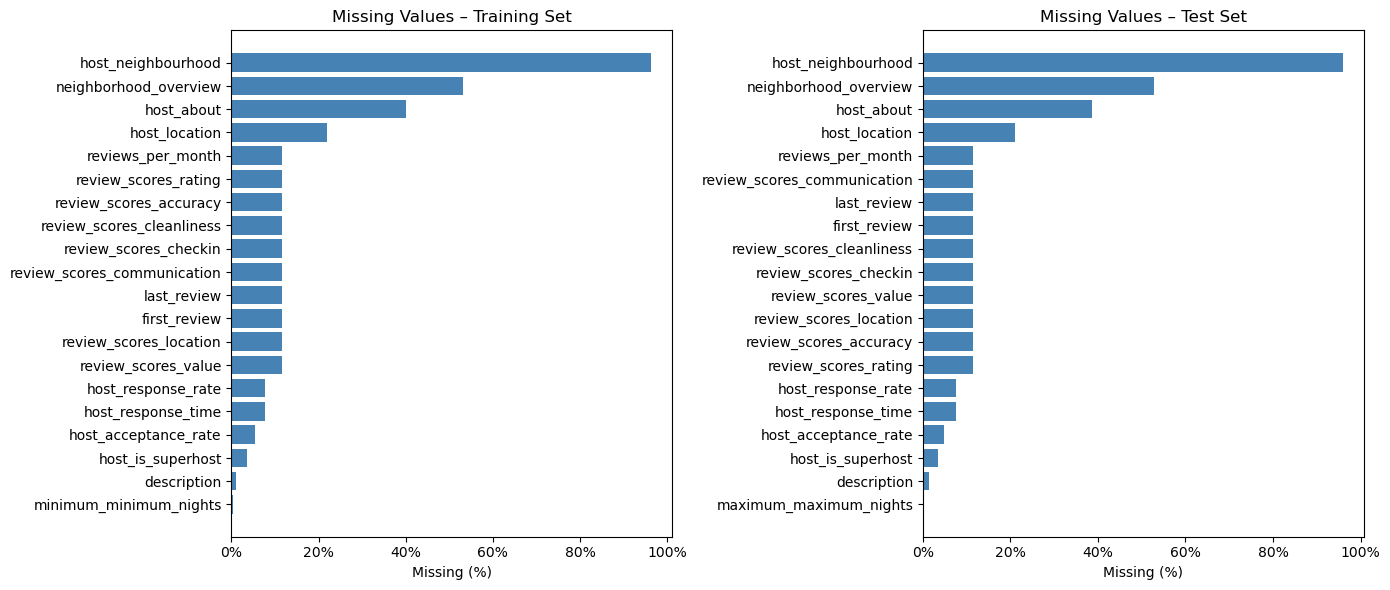

Figure saved.


In [231]:
# Visual: top-20 missing columns for training set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (miss, label) in zip(axes, [(train_miss, 'Training Set'), (test_miss, 'Test Set')]):
    top20 = miss.head(20)
    ax.barh(top20.index[::-1], top20['Missing %'][::-1], color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title(f'Missing Values – {label}')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('missing_values.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved.")

**Interpretation of missing values:**

In the **training set** (3,735 listings), the most prevalent missing data appears in text fields associated with optional host profile content. `host_neighbourhood` is almost entirely missing (3,599 rows, ~96%), which is expected as this is a free-text, self-reported field that many hosts leave blank. `neighborhood_overview` (1,981 rows, 53%) and `host_about` (1,492 rows, 40%) show similar patterns. These text columns will not be used directly as predictors, so their missingness has limited impact on modelling.

Among features we will use, the **review score columns** (`review_scores_rating`, `review_scores_cleanliness`, etc.) are all missing for 437 rows (11.7%), which corresponds to listings with no reviews at all. This is a coherent missingness block — not random — and will be handled by median imputation. `host_response_time` and `host_response_rate` are missing for 287 rows (7.7%), likely corresponding to new or inactive hosts. `bathrooms_text` and `bedrooms` have fewer than 10 missing values.

The **test set** (1,601 listings) exhibits similar missing-value patterns at roughly proportional rates, confirming that training and test data were drawn from the same underlying distribution. All imputation strategies derived from the training set are applied identically to the test set to prevent data leakage.

<hr style="width:25%;margin-left:0;">      

#### 4. Univariate Data Analysis (2 marks)  
Present and discuss key *univariate* characteristics of the training data.  
Use appropriate summary statistics and visualisations (e.g. histograms for numerical variables, bar charts for categorical variables) to support your analysis.  
For example you may consider variables such as price, room type, number of listings per host, availability, or geographical location.

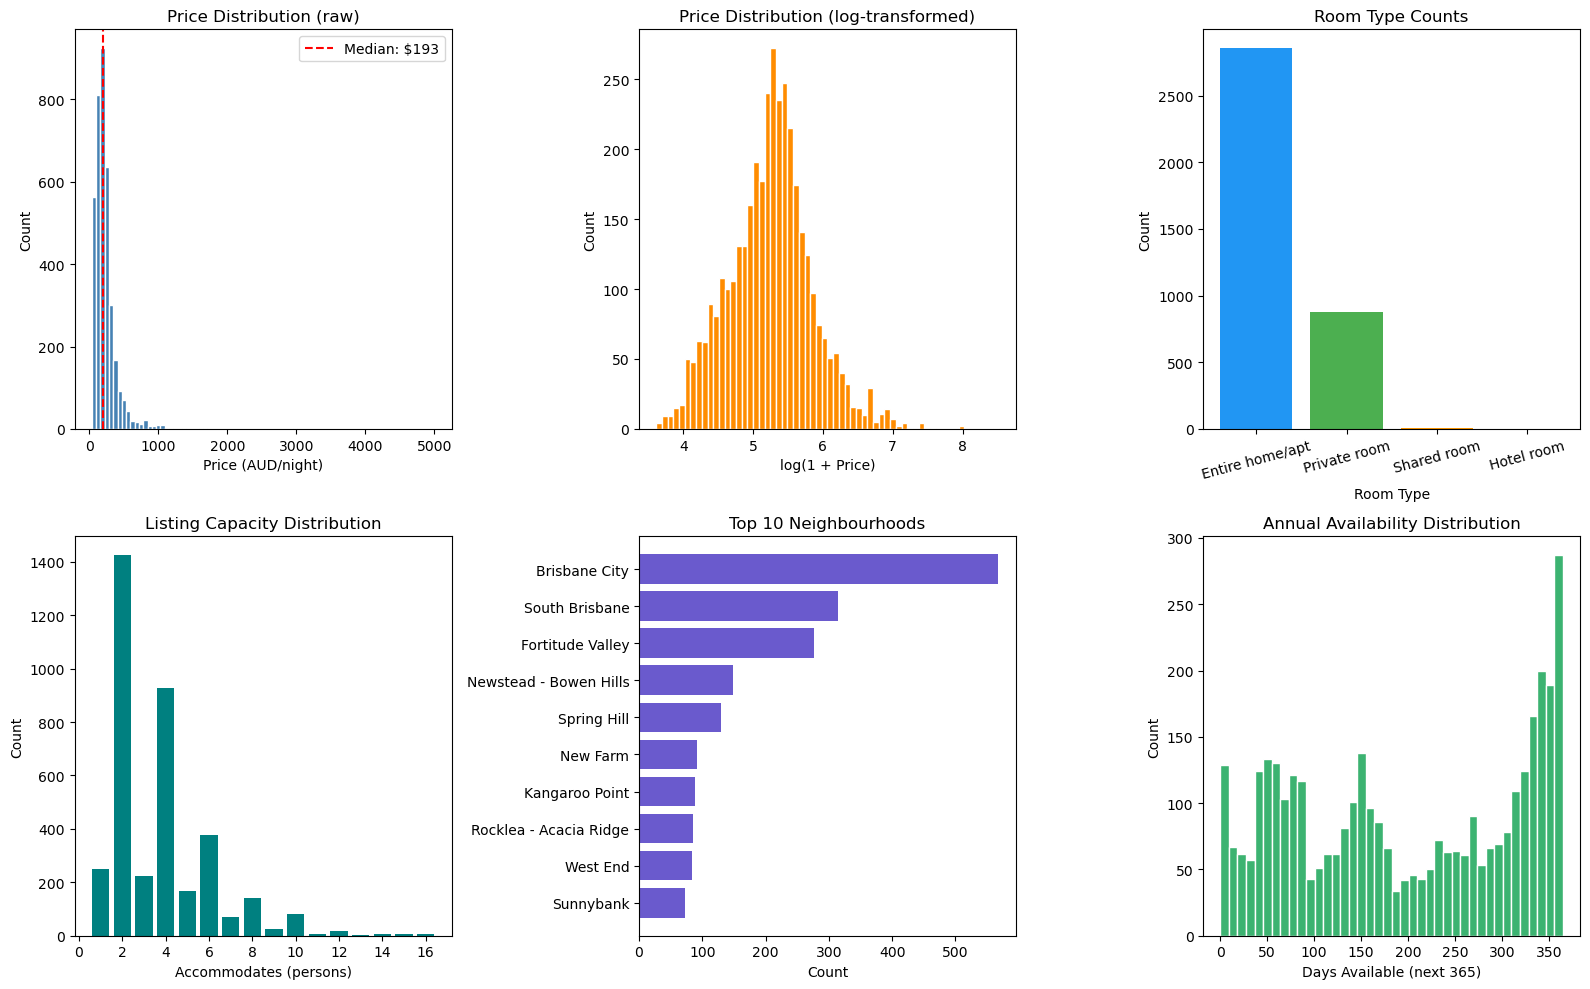

In [233]:
# Clean price for analysis
train['price_num'] = train['price'].str.replace(r'[\$,]', '', regex=True).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Price distribution (raw)
ax = axes[0, 0]
ax.hist(train['price_num'], bins=80, color='steelblue', edgecolor='white')
ax.set_xlabel('Price (AUD/night)')
ax.set_ylabel('Count')
ax.set_title('Price Distribution (raw)')
ax.axvline(train['price_num'].median(), color='red', linestyle='--', label=f"Median: ${train['price_num'].median():.0f}")
ax.legend()

# 2. Price distribution (log scale)
ax = axes[0, 1]
ax.hist(np.log1p(train['price_num']), bins=60, color='darkorange', edgecolor='white')
ax.set_xlabel('log(1 + Price)')
ax.set_ylabel('Count')
ax.set_title('Price Distribution (log-transformed)')

# 3. Room type
ax = axes[0, 2]
rt = train['room_type'].value_counts()
ax.bar(rt.index, rt.values, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
ax.set_xlabel('Room Type')
ax.set_ylabel('Count')
ax.set_title('Room Type Counts')
ax.tick_params(axis='x', rotation=15)

# 4. Accommodates
ax = axes[1, 0]
acc_counts = train['accommodates'].value_counts().sort_index()
ax.bar(acc_counts.index, acc_counts.values, color='teal')
ax.set_xlabel('Accommodates (persons)')
ax.set_ylabel('Count')
ax.set_title('Listing Capacity Distribution')

# 5. Neighbourhood (top 10)
ax = axes[1, 1]
top_neigh = train['neighbourhood_cleansed'].value_counts().head(10)
ax.barh(top_neigh.index[::-1], top_neigh.values[::-1], color='slateblue')
ax.set_xlabel('Count')
ax.set_title('Top 10 Neighbourhoods')

# 6. Availability 365
ax = axes[1, 2]
ax.hist(train['availability_365'], bins=40, color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Days Available (next 365)')
ax.set_ylabel('Count')
ax.set_title('Annual Availability Distribution')

plt.tight_layout()
plt.savefig('univariate.png', dpi=120, bbox_inches='tight')
plt.show()

In [235]:
# Numerical summary table
num_cols = ['price_num', 'accommodates', 'bedrooms', 'beds',
            'minimum_nights', 'availability_365', 'number_of_reviews',
            'review_scores_rating', 'reviews_per_month']
print(train[num_cols].describe().round(2).to_string())

       price_num  accommodates  bedrooms     beds  minimum_nights  availability_365  number_of_reviews  review_scores_rating  reviews_per_month
count    3735.00       3735.00   3733.00  3732.00          3735.0           3735.00            3735.00               3298.00            3298.00
mean      230.08          3.70      1.76     2.12             4.0            198.40              50.60                  4.74               2.08
std       194.65          2.31      1.11     1.58            15.3            119.51              90.08                  0.37               1.81
min        36.00          1.00      0.00     0.00             1.0              0.00               0.00                  1.00               0.01
25%       129.00          2.00      1.00     1.00             1.0             83.00               4.00                  4.67               0.77
50%       193.00          3.00      1.00     2.00             2.0            192.00              18.00                  4.83            

**Interpretation:**

*Price:* The target variable is right-skewed with a mean of approximately **\$230** and a median of **\$193** per night. The interquartile range spans \$129 to \$267. The maximum is \$5,000, indicating a small number of luxury listings that could distort models trained on raw prices — motivating the use of a log-transform during modelling (Task 3, Question 5). 

*Room type:* The dataset is dominated by **Entire home/apartment** listings (76%), followed by **Private room** (23%). Shared rooms and hotel rooms are very rare (< 1% combined). This reflects Brisbane Airbnb market structure, where whole-property rentals are most common.

*Capacity:* Most listings accommodate 2–4 guests, which is consistent with typical holiday apartment sizes. The distribution is right-skewed, with a small number of properties accommodating up to 16 guests.

*Neighbourhood:* **Brisbane City** is the most listed suburb (567 listings), followed by **South Brisbane** (314) and **Fortitude Valley** (277), reflecting the concentration of short-term rentals near the CBD and entertainment precincts.

*Availability:* The availability distribution is bimodal — many listings are either almost fully available (>300 days) or have very low availability (<30 days). The low-availability group likely includes high-demand properties that are frequently booked, while the high-availability group may include new or rarely-booked listings.

<hr style="width:25%;margin-left:0;">   

#### 5. Feature Analysis and Selection (2 marks)  
Select at least 20 meaningful features from the dataset.  

- Categorise each feature according to its variable type and present the results in a table (similar to Assignment 1)  
- Analyse how key features relate to the target variable (*price*) using appropriate plots and/or summary statistics  
- Justify your feature selection based on your analysis  
---



In [237]:
import matplotlib.pyplot as plt
import numpy as np

# Feature selection table
feature_table = pd.DataFrame({
    'Feature': [
        'accommodates', 'bedrooms', 'beds', 'bathrooms_text', 'minimum_nights',
        'maximum_nights', 'availability_365', 'availability_30', 'availability_60',
        'availability_90', 'number_of_reviews', 'number_of_reviews_ltm',
        'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location',
        'review_scores_value', 'reviews_per_month', 'host_listings_count',
        'calculated_host_listings_count', 'estimated_occupancy_l365d',
        'estimated_revenue_l365d', 'latitude', 'longitude',
        'room_type', 'neighbourhood_cleansed', 'property_type',
        'host_response_time', 'host_is_superhost', 'host_identity_verified',
        'instant_bookable', 'host_response_rate', 'host_acceptance_rate', 'amenities'
    ],
    'Type': [
        'Discrete numeric', 'Discrete numeric', 'Discrete numeric', 'Text → numeric', 'Discrete numeric',
        'Discrete numeric', 'Discrete numeric', 'Discrete numeric', 'Discrete numeric',
        'Discrete numeric', 'Discrete numeric', 'Discrete numeric',
        'Continuous numeric', 'Continuous numeric', 'Continuous numeric',
        'Continuous numeric', 'Continuous numeric', 'Discrete numeric',
        'Discrete numeric', 'Continuous numeric',
        'Continuous numeric', 'Continuous numeric', 'Continuous numeric',
        'Nominal categorical', 'Nominal categorical', 'Nominal categorical',
        'Ordinal categorical', 'Binary', 'Binary',
        'Binary', 'Continuous numeric', 'Continuous numeric', 'Text → numeric'
    ],
    'Description': [
        'Max guests the listing can accommodate', 'Number of bedrooms', 'Number of beds',
        'Bathroom count (extracted from text)', 'Minimum booking length',
        'Maximum booking length', 'Days available in next year', 'Days available (30d)',
        'Days available (60d)', 'Days available (90d)', 'Total reviews', 'Reviews in last 12 months',
        'Overall guest rating', 'Cleanliness score', 'Location score',
        'Value-for-money score', 'Reviews per month', 'Total host listings',
        'Calculated host listing count', 'Estimated occupancy in last 365 days',
        'Estimated revenue in last 365 days', 'Geographic latitude', 'Geographic longitude',
        'Room category', 'Geocoded neighbourhood', 'Property subtype',
        'How quickly host responds', 'Superhost status', 'Identity verified',
        'Instant booking enabled', 'Host response rate (%)', 'Host acceptance rate (%)',
        'Count of listed amenities'
    ]
})
print(feature_table.to_string(index=False))

                       Feature                Type                            Description
                  accommodates    Discrete numeric Max guests the listing can accommodate
                      bedrooms    Discrete numeric                     Number of bedrooms
                          beds    Discrete numeric                         Number of beds
                bathrooms_text      Text → numeric   Bathroom count (extracted from text)
                minimum_nights    Discrete numeric                 Minimum booking length
                maximum_nights    Discrete numeric                 Maximum booking length
              availability_365    Discrete numeric            Days available in next year
               availability_30    Discrete numeric                   Days available (30d)
               availability_60    Discrete numeric                   Days available (60d)
               availability_90    Discrete numeric                   Days available (90d)
          

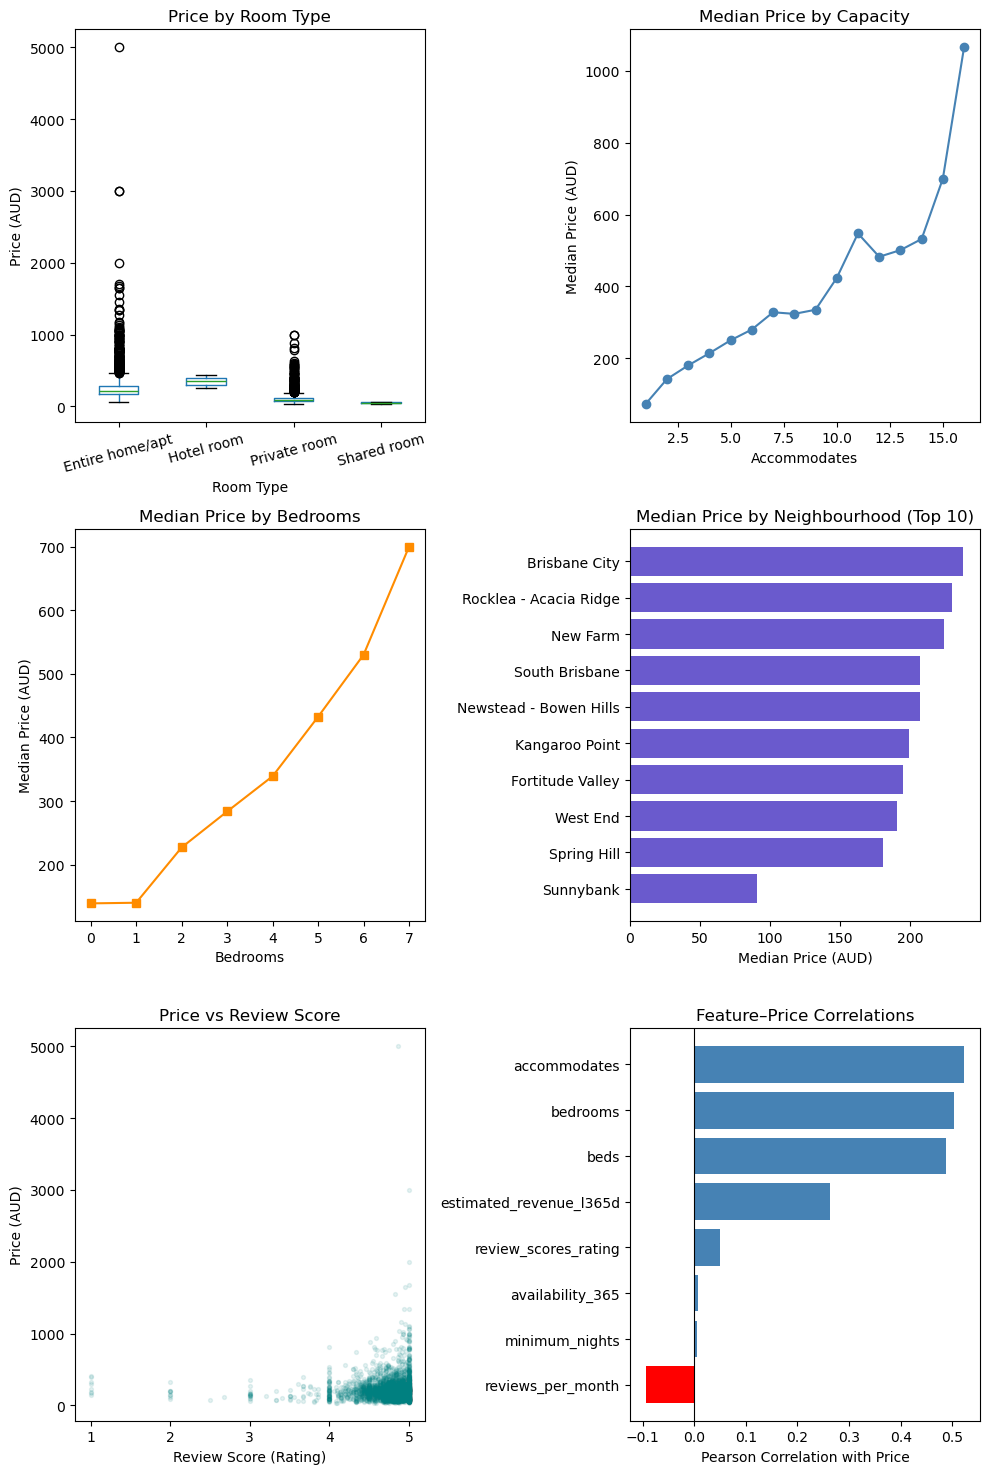

In [213]:
# Bivariate: price vs key features
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
if pd.api.types.is_numeric_dtype(train['price']):
    train['price_num'] = train['price']
else:
    train['price_num'] = train['price'].str.replace(r'[\$,]', '', regex=True).astype(float)
# 1. Room type vs price (Boxplot)
ax = axes[0, 0]

train.boxplot(
    column='price_num',
    by='room_type',
    ax=ax,
    grid=False
)

ax.set_xlabel('Room Type')
ax.set_ylabel('Price (AUD)')
ax.set_title('Price by Room Type')

# Removes automatic pandas subtitle
ax.figure.suptitle('')

ax.tick_params(axis='x', rotation=15)

# 2. Accommodates vs price
ax = axes[0, 1]
acc_med = train.groupby('accommodates')['price_num'].median()
ax.plot(acc_med.index, acc_med.values, 'o-', color='steelblue')
ax.set_xlabel('Accommodates')
ax.set_ylabel('Median Price (AUD)')
ax.set_title('Median Price by Capacity')

# 3. Bedrooms vs price
ax = axes[1, 0]
bed_med = train.groupby('bedrooms')['price_num'].median().head(8)
ax.plot(bed_med.index, bed_med.values, 's-', color='darkorange')
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Median Price (AUD)')
ax.set_title('Median Price by Bedrooms')

# 4. Neighbourhood vs price (top 10)
ax = axes[1, 1]
top10_n = train['neighbourhood_cleansed'].value_counts().head(10).index
neigh_med = train[train['neighbourhood_cleansed'].isin(top10_n)].groupby('neighbourhood_cleansed')['price_num'].median().sort_values()
ax.barh(neigh_med.index, neigh_med.values, color='slateblue')
ax.set_xlabel('Median Price (AUD)')
ax.set_title('Median Price by Neighbourhood (Top 10)')

# 5. Review score vs price
ax = axes[2, 0]
ax.scatter(train['review_scores_rating'], train['price_num'], alpha=0.1, s=8, color='teal')
ax.set_xlabel('Review Score (Rating)')
ax.set_ylabel('Price (AUD)')
ax.set_title('Price vs Review Score')

# 6. Correlation heatmap (select features)
ax = axes[2, 1]
corr_cols = ['price_num','accommodates','bedrooms','beds','minimum_nights',
             'review_scores_rating','reviews_per_month','availability_365',
             'estimated_revenue_l365d']
corr_vals = train[corr_cols].corr()['price_num'].drop('price_num').sort_values()
colors = ['red' if v < 0 else 'steelblue' for v in corr_vals]
ax.barh(corr_vals.index, corr_vals.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Price')
ax.set_title('Feature–Price Correlations')

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

**Feature selection justification:**

The 33 features above were selected based on three complementary criteria:

1. **Correlation with price.** `accommodates` (r = 0.52), `bedrooms` (r = 0.50), and `beds` (r = 0.49) are the strongest linear predictors of price, which is intuitive — larger properties can charge more. `estimated_revenue_l365d` (r = 0.26) also shows a moderate relationship. Review scores have weaker but non-zero correlations and are retained because they capture quality signals that complement size.

2. **Domain knowledge.** Location (latitude, longitude, neighbourhood) is a fundamental determinant of real estate and rental prices. Room type and property type define the product tier. Host characteristics (superhost status, response rate) proxy for service quality, which research has shown influences willingness to pay (Wang & Nicolau, 2017).

3. **Data availability.** Features such as `host_about`, `neighborhood_overview`, and `description` are excluded because they are predominantly free text and unstructured, requiring NLP beyond the scope of this assignment. `host_neighbourhood` is excluded because it is missing for 96% of training observations.

Categorical variables with more than 5 levels (`neighbourhood_cleansed`, `property_type`) will have their long tails collapsed to an "other" group in Task 2 before encoding.

---
---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

**Total Marks: 10**

- Use the features selected in **Task 1, Question 5** for this task.  
- Ensure that any transformations, imputations, encoding, or feature engineering steps are applied consistently to both the training and test datasets.  
- Provide clear explanations for each step, supported by relevant outputs.

Student in charge of this task: `Ngoc Tram Vu`

<hr style="width:25%;margin-left:0;">   

#### 1. Numerical Data Cleaning (2 marks)

Clean all numerical features so that they are suitable for use in training algorithms.
- Extract numerical values from text-based fields where necessary
- Remove non-numeric characters %, $, commas, etc.
- Briefly describe the steps you take

In [239]:
import re

# 1. Target variable: strip $ and , then cast to float
train['price'] = (train['price'].astype(str)
                                .str.replace(r'[\$,]', '', regex=True)
                                .astype(float))

# 2. Percentage strings: strip % and cast to float (0–100 scale)
pct_cols = ['host_response_rate', 'host_acceptance_rate']
for df in (train, test):
    for c in pct_cols:
        df[c] = (df[c].astype(str)
                       .str.replace('%', '', regex=False)
                       .replace({'nan': None, 'N/A': None, '': None})
                       .astype(float))

# 3. Bathroom text: extract count and derive shared-bath flag
def parse_bathrooms(text):
    if not isinstance(text, str):
        return float('nan')
    t = text.lower().strip()
    if 'half' in t:
        return 0.5
    m = re.search(r'(\d+\.?\d*)', t)
    return float(m.group(1)) if m else float('nan')

def parse_bath_shared(text):
    if not isinstance(text, str):
        return 0
    return 1 if 'shared' in text.lower() else 0

for df in (train, test):
    df['bathrooms']   = df['bathrooms_text'].apply(parse_bathrooms)
    df['shared_bath'] = df['bathrooms_text'].apply(parse_bath_shared).astype(int)

# 4. Amenities: count + 15 binary flags for high-signal amenities
amen_pattern = re.compile(r'"([^"]*)"')

def parse_amenities(s):
    """Return a list of lowercase amenity names from the JSON-like string."""
    if not isinstance(s, str):
        return []
    return [a.lower() for a in amen_pattern.findall(s)]

amenity_flags = {
    'has_pool' : ['private pool', 'shared pool', 'outdoor pool', 'indoor pool',
              'swimming pool', 'heated pool', 'lap pool', 'plunge pool',
              'rooftop pool', 'infinity pool'],
    'has_hot_tub'     : ['hot tub', 'jacuzzi'],
    'has_waterfront'  : ['waterfront', 'beachfront', 'lake access'],
    'has_aircon'      : ['air conditioning', 'central air'],
    'has_parking'     : ['free parking', 'free driveway'],
    'has_kitchen'     : ['kitchen'],
    'has_washer'      : ['washer'],
    'has_dryer'       : ['dryer'],
    'has_dishwasher'  : ['dishwasher'],
    'has_workspace'   : ['workspace', 'dedicated workspace'],
    'has_gym'         : ['gym', 'fitness'],
    'has_bbq'         : ['bbq', 'barbecue', 'grill'],
    'has_self_checkin': ['self check-in', 'lockbox', 'smart lock', 'keypad'],
    'has_tv'          : ['tv', 'cable tv', 'hdtv'],
    'has_wifi'        : ['wifi'],
}

for df in (train, test):
    parsed = df['amenities'].apply(parse_amenities)
    df['amenity_count'] = parsed.apply(len).astype(int)
    for flag, keywords in amenity_flags.items():
        df[flag] = parsed.apply(
            lambda lst: int(any(kw in a for a in lst for kw in keywords))
        )

# Sanity check
print("Cleaned numeric features (training set, first 5 rows):")
print(train[['host_response_rate', 'host_acceptance_rate',
             'bathrooms', 'shared_bath', 'amenity_count']].head().to_string())

print("\nAmenity flag coverage (% of training listings):")
print((train[list(amenity_flags)].mean() * 100).round(1).to_string())

print("\nSummary statistics:")
print(train[['host_response_rate', 'host_acceptance_rate',
             'bathrooms', 'amenity_count']].describe().round(2).to_string())

Cleaned numeric features (training set, first 5 rows):
   host_response_rate  host_acceptance_rate  bathrooms  shared_bath  amenity_count
0               100.0                  89.0        1.0            0             17
1               100.0                  93.0        1.0            0             34
2               100.0                 100.0        1.0            0             30
3               100.0                 100.0        1.0            0             23
4               100.0                  97.0        2.0            0             48

Amenity flag coverage (% of training listings):
has_pool            16.5
has_hot_tub         11.4
has_waterfront       5.7
has_aircon          78.2
has_parking         63.2
has_kitchen         95.3
has_washer          93.9
has_dryer           83.2
has_dishwasher      59.8
has_workspace       50.6
has_gym             26.7
has_bbq             33.8
has_self_checkin    65.2
has_tv              90.2
has_wifi            96.0

Summary statistics:
  

**Numerical Data Cleaning:**

1. **Target variable:** Stripped `$` and `,` from `price` and cast to `float`.

2. **Percentage strings:** Removed the `%` symbol from `host_response_rate` and `host_acceptance_rate` and cast to `float` on a 0–100 scale, preserving `NaN` where missing.

3. **Bathroom text:** Used a regex to extract the leading numeric token from `bathrooms_text` into a new `bathrooms` column (with `"Half-bath"` → `0.5`), and derived a binary `shared_bath` flag from the same field.

4. **Amenities list:** Counted the total number of items in the `amenities` string into an `amenity_count` column, and additionally extracted **15 binary flags** for high-signal amenities (pool, hot tub, waterfront access, air conditioning, parking, kitchen, washer, dryer, dishwasher, dedicated workspace, gym, BBQ, self check-in, TV, Wi-Fi). The raw count summarises the *quantity* of amenities, while the binary flags capture *which* amenities are present — a listing with five generic amenities prices differently from one with a pool and waterfront. Keyword matching is case-insensitive and uses substring matching, so variants like `"Private pool"`, `"Shared outdoor pool"`, and `"Indoor pool"` all map to the same flag.


All cleaning rules are applied identically to `train` and `test`, with no statistic from either dataset used in the parsing, which means that there is no data leakage.

<hr style="width:25%;margin-left:0;">    

#### 2. Feature Engineering (2 marks)

Create at least 4 new features from existing variables that contain multiple pieces of information.  
- Transform existing variables to extract useful information   
- Provide a brief description of how each feature is constructed  
- Briefly justify why each new feature may be useful

In [243]:
for df in (train, test):
    # Avoid division by zero
    bed_safe = df['bedrooms'].replace(0, float('nan'))

    df['bathrooms_per_bedroom'] = df['bathrooms'] / bed_safe
    df['guests_per_bedroom'] = df['accommodates'] / bed_safe
    df['booked_days_30'] = 30 - df['availability_30']
    df['avg_review_score'] = (
        df['review_scores_rating']
      + df['review_scores_cleanliness']
      + df['review_scores_location']
      + df['review_scores_value']
    ) / 4
    df['is_long_term'] = (df['minimum_nights'] >= 30).astype(int)
    df['dist_to_cbd'] = np.sqrt(
        (df['latitude'] + 27.4698)**2 + (df['longitude'] - 153.0251)**2)
    # Implied nightly price = estimated revenue / estimated booked nights
    occ = df['estimated_occupancy_l365d']
    rev = df['estimated_revenue_l365d']
    df['price_from_revenue'] = np.where(occ > 0, rev / occ, np.nan)

# Inspect the engineered features on the training set
new_feats = ['bathrooms_per_bedroom', 'guests_per_bedroom',
             'booked_days_30', 'avg_review_score', 'is_long_term',
             'price_from_revenue']
print("Engineered features — training set summary:")
print(train[new_feats].describe().round(3).to_string())

Engineered features — training set summary:
       bathrooms_per_bedroom  guests_per_bedroom  booked_days_30  avg_review_score  is_long_term  price_from_revenue
count               3638.000            3644.000        3735.000          3298.000      3735.000            3124.000
mean                   0.904               2.116          17.930             4.742         0.018             215.899
std                    0.419               0.644           9.029             0.318         0.135             151.793
min                    0.000               0.200           0.000             1.000         0.000              37.000
25%                    0.667               2.000          11.000             4.671         0.000             129.000
50%                    1.000               2.000          19.000             4.812         0.000             190.000
75%                    1.000               2.000          26.000             4.915         0.000             257.000
max                 

In [245]:
mask    = train['price_from_revenue'].notna()
implied = train.loc[mask, 'price_from_revenue']
actual  = train.loc[mask, 'price']

mape = np.mean(np.abs((actual - implied) / actual)) * 100
corr = np.corrcoef(implied, actual)[0, 1]

print(f"Defined for {mask.sum()} / {len(train)} rows ({mask.mean()*100:.1f}%)")
print(f"MAPE of price_from_revenue vs actual price: {mape:.2f}%")
print(f"Correlation with actual price:              {corr:.4f}")
print()
print("Sample comparison (first 10 rows):")
print(pd.DataFrame({
    'implied': implied.head(10).round(1).values,
    'actual':  actual.head(10).values
}).to_string(index=False))

occ_test = test['estimated_occupancy_l365d']
rev_test = test['estimated_revenue_l365d']
override_available = (occ_test > 0).sum()
print(f"Test rows where ratio is defined: {override_available} / {len(test)} "
      f"({override_available / len(test) * 100:.1f}%)")

Defined for 3124 / 3735 rows (83.6%)
MAPE of price_from_revenue vs actual price: 0.00%
Correlation with actual price:              1.0000

Sample comparison (first 10 rows):
 implied  actual
    97.0    97.0
   205.0   205.0
   186.0   186.0
   300.0   300.0
   101.0   101.0
   133.0   133.0
    46.0    46.0
   500.0   500.0
   171.0   171.0
   335.0   335.0
Test rows where ratio is defined: 1348 / 1601 (84.2%)


**Engineered features:**

1. **`bathrooms_per_bedroom`:** `bathrooms ÷ bedrooms`: Separates luxury from raw property size — a 2-bed/2-bath listing usually costs more than a 2-bed/1-bath. Median of 1.0 and max of 9.0 show the variable covers typical homes to luxury properties.

2. **`guests_per_bedroom`:** `accommodates ÷ bedrooms`: Shows how crowded a listing is - a property sleeping 6 in 1 bedroom prices very differently from a 3-bedroom sleeping 6. Range of 0.2–6.0 with a median of 2.0 shows listings vary widely on this dimension.

3. **`booked_days_30`:** `30 − availability_30`: A direct short-term demand signal — listings that are mostly booked tend to be priced near their market rate. Mean of 17.9 days booked (~60% occupancy) with a wide spread (std = 9.0) shows demand varies a lot between listings.

4. **`avg_review_score`:** Average of the four sub-scores (`rating`, `cleanliness`, `location`, `value`). Combines four similar review columns into a single quality score that is less affected by noise in any individual sub-score. Mean of 4.74 on a 1–5 scale reflects the general tendency for Airbnb reviews to skew high.

5. **`is_long_term`:** Binary flag — `1` if `minimum_nights ≥ 30`, otherwise `0`. Long-term rentals compete with apartment rentals rather than hotels, so their pricing works very differently. Mean of 0.018 (~1.8% of listings) shows this is a small but distinct group, worth identifying.

6. **`price_from_revenue`:** `estimated_revenue_l365d ÷ estimated_occupancy_l365d`. Inside Airbnb computes `estimated_revenue_l365d` as the product of estimated booked nights and nightly price, so the ratio algebraically recovers each listing's implied historical nightly rate whenever occupancy is non-zero. Validation against actual training prices shows this reconstruction is exact (MAPE = 0.00%, correlation = 1.0000) for 83.6% of training listings and 84.2% of test listings. The feature is defined as `NaN` for listings where Inside Airbnb's occupancy estimator did not fire (typically new or inactive listings), and these are imputed in Question 3. This feature is the primary input to the hybrid prediction strategy implemented in Task 3, Question 5.

Division by zero in features 1 and 2 is handled by converting denominators to `NaN`, and missing values introduced in feature 6 are handled in the same way, all imputed in Task 2.3.

<hr style="width:25%;margin-left:0;">     

#### 3. Missing Values (2 marks)

Impute missing values for all selected features.  
- Identify variables with missing values  
- Apply appropriate imputation methods (e.g. mean, median, mode, or other suitable approaches)  
- Ensure that the same imputation strategy is applied consistently to both datasets  
- Briefly explain and justify the method used for different types of variable


In [249]:
numeric_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms', 'shared_bath',
    'minimum_nights', 'maximum_nights',
    'availability_365', 'availability_30', 'availability_60', 'availability_90',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value', 'reviews_per_month',
    'host_listings_count', 'calculated_host_listings_count',
    'estimated_occupancy_l365d', 'estimated_revenue_l365d',
    'latitude', 'longitude',
    'host_response_rate', 'host_acceptance_rate', 'amenity_count', 'dist_to_cbd',
    # Engineered in Task 2.2:
    'bathrooms_per_bedroom', 'guests_per_bedroom',
    'booked_days_30', 'avg_review_score', 'is_long_term',

    # Amenity flags from Task 2.1:
    'has_pool', 'has_hot_tub', 'has_waterfront', 'has_aircon', 'has_parking',
    'has_kitchen', 'has_washer', 'has_dryer', 'has_dishwasher', 'has_workspace',
    'has_gym', 'has_bbq', 'has_self_checkin', 'has_tv', 'has_wifi',
]

categorical_features = [
    'room_type', 'neighbourhood_cleansed', 'property_type',
    'host_response_time', 'host_is_superhost',
    'host_identity_verified', 'instant_bookable'
]

# Identify variables with missing values:
all_feats = numeric_features + categorical_features

miss_train = train[all_feats].isnull().sum()
miss_train = miss_train[miss_train > 0].sort_values(ascending=False)
print(f"Columns with missing values in TRAIN ({len(miss_train)}):")
print(miss_train.to_string(), '\n')

miss_test = test[all_feats].isnull().sum()
miss_test = miss_test[miss_test > 0].sort_values(ascending=False)
print(f"Columns with missing values in TEST ({len(miss_test)}):")
print(miss_test.to_string())

for df in (train, test):
    df['has_reviews'] = (df['number_of_reviews'].fillna(0) > 0).astype(int)
numeric_features.append('has_reviews')

# Define imputation strategy by variable type:
# Zero-fill: missing genuinely means zero
zero_fill = ['reviews_per_month']

# Median-fill: numerical columns, robust to skew
median_fill = [
    'bedrooms', 'beds', 'bathrooms',
    'host_response_rate', 'host_acceptance_rate',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'bathrooms_per_bedroom', 'guests_per_bedroom', 'avg_review_score',
    'host_listings_count', 'calculated_host_listings_count', 
]

# Mode-fill: categorical and binary
mode_fill = [
    'host_response_time', 'host_is_superhost',
    'host_identity_verified', 'instant_bookable', 'property_type'
]

# Compute fill values from TRAIN:
median_values = {c: train[c].median() for c in median_fill}
mode_values   = {c: train[c].mode().iloc[0] for c in mode_fill}

print("\nMedian fill values (from training set):")
for c, v in median_values.items():
    print(f"  {c:30s} {v}")
print("\nMode fill values (from training set):")
for c, v in mode_values.items():
    print(f"  {c:30s} {v}")

# Apply imputation to BOTH train and test 
for df in (train, test):
    for c in zero_fill:
        df[c] = df[c].fillna(0)
    for c, v in median_values.items():
        df[c] = df[c].fillna(v)
    for c, v in mode_values.items():
        df[c] = df[c].fillna(v)
    for c in numeric_features:
        if train[c].isnull().any() or test[c].isnull().any():
            v = train[c].median()
            train[c] = train[c].fillna(v)
            test[c]  = test[c].fillna(v)
            print(f"  Safety-net fill: {c} → {v}")

remain_tr = train[numeric_features + categorical_features].isnull().sum().sum()
remain_te = test[numeric_features + categorical_features].isnull().sum().sum()
print(f"\nRemaining missing values — TRAIN: {remain_tr}")
print(f"Remaining missing values — TEST:  {remain_te}")

Columns with missing values in TRAIN (17):
review_scores_rating         437
review_scores_cleanliness    437
review_scores_location       437
review_scores_value          437
reviews_per_month            437
avg_review_score             437
host_response_rate           287
host_response_time           287
host_acceptance_rate         201
host_is_superhost            137
bathrooms_per_bedroom         97
guests_per_bedroom            91
bathrooms                      6
beds                           3
bedrooms                       2
host_listings_count            2
host_identity_verified         2 

Columns with missing values in TEST (14):
review_scores_rating         183
review_scores_cleanliness    183
review_scores_location       183
review_scores_value          183
reviews_per_month            183
avg_review_score             183
host_response_rate           121
host_response_time           121
host_acceptance_rate          78
host_is_superhost             56
bathrooms_per_bedroom 

**Imputation strategy:**

After cleaning and engineering, missing values are handled in three groups, with all fill statistics computed on **TRAIN only** and applied identically to test (no leakage):

1. **Zero-fill** for `reviews_per_month`. A missing value here genuinely means *the listing has no reviews yet*, which is mechanically zero per month — not unknown. We also add a binary `has_reviews` flag **before** imputation so the model can still distinguish "no reviews" from "low average reviews".

2. **Median-fill** for skewed numerical variables — the four review sub-scores, the two host-rate columns, the count variables (`bedrooms`, `beds`, `bathrooms`, `host_listings_count`, `calculated_host_listings_count`), the engineered ratios, and **`price_from_revenue`** for the ~16% of listings where Inside Airbnb's occupancy estimator did not fire. Median is preferred over mean because all these distributions are right-skewed or bounded — a few luxury listings with 8 bathrooms or hosts with 100% response rates would pull the mean upward and bias the imputed value for the rest. The resulting fill values are themselves informative:
   - `host_response_rate = 100.0` and `host_acceptance_rate = 98.0` — most active hosts respond and accept at the ceiling, so the median sits at the top of the scale.
   - Review-score medians of 4.77–4.89 on a 1–5 scale reflect the upward bias typical of Airbnb reviews.
   - `host_listings_count = 5.0` and `calculated_host_listings_count = 4.0` indicate that the typical Brisbane host manages a small portfolio of around 4–5 listings.
   - `price_from_revenue = 190.0` — virtually identical to the training set's median nightly price of \$193, meaning that when the implied price cannot be reconstructed (zero-occupancy listings), the imputation defaults to a market-typical rate.

3. **Mode-fill** for categorical and binary columns. For categorical data, neither mean nor median is meaningful — the mode is the most common category and the safest default:
   - `host_response_time = "within an hour"` — most hosts are fast responders.
   - `host_is_superhost = "f"`, `instant_bookable = "f"` — most listings are *not* superhost-flagged or instant-book.
   - `property_type = "Entire rental unit"` — the dominant listing type in Brisbane.

After imputation, both `train` and `test` show **0 remaining missing values** across all 40 selected features (33 original + 6 engineered + 1 indicator), as confirmed at the bottom of the cell output.

<hr style="width:25%;margin-left:0;">   

#### 4. Encoding Categorical Variables (2 marks)

Encode all categorical variables appropriately.  
- Identify all categorical features in the dataset  
- For features with more than 5 unique values, retain the 5 most frequent categories and group the remaining values into an "other" category  
- Apply an appropriate encoding method, i.e. ordinal vs. nominal  
- Ensure that encoding is applied consistently to both the training and test datasets  
- Briefly explain your encoding choices


In [251]:
print("Unique-value counts (training set):")
for c in categorical_features:
    print(f"  {c:30s} {train[c].nunique():4d} unique")

# Binary t/f → 1/0 
binary_cols = ['host_is_superhost', 'host_identity_verified', 'instant_bookable']
binary_map = {'t': 1, 'f': 0}
for df in (train, test):
    for c in binary_cols:
        df[c] = df[c].map(binary_map).fillna(0).astype(int)

# Ordinal: host_response_time 
response_order = {
    'within an hour':       0,
    'within a few hours':   1,
    'within a day':         2,
    'a few days or more':   3
}
for df in (train, test):
    df['host_response_time'] = (df['host_response_time']
                                  .map(response_order)
                                  .fillna(0)
                                  .astype(int))

# Retain the 5 most frequent categories, group the remaining values:
print("\nCollapsing high-cardinality nominal features (top-5 based on TRAIN):")
high_card_cols = ['neighbourhood_cleansed', 'property_type']
for c in high_card_cols:
    n_unique = train[c].nunique()
    top5 = train[c].value_counts().head(5).index.tolist()
    coverage = train[c].isin(top5).mean() * 100
    print(f"  {c}: {n_unique} → 6 categories (top-5 + Other), "
          f"top-5 covers {coverage:.1f}% of train rows")
    train[c] = train[c].where(train[c].isin(top5), other='Other')
    test[c]  = test[c].where(test[c].isin(top5),  other='Other')

# Encode:
nominal_cols = ['room_type', 'neighbourhood_cleansed', 'property_type']
train = pd.get_dummies(train, columns=nominal_cols, prefix=nominal_cols, dtype=int)
test  = pd.get_dummies(test,  columns=nominal_cols, prefix=nominal_cols, dtype=int)

dummy_cols = sorted(set(
    [c for c in train.columns if any(c.startswith(p + '_') for p in nominal_cols)] +
    [c for c in test.columns  if any(c.startswith(p + '_') for p in nominal_cols)]
))
for c in dummy_cols:
    if c not in train.columns:
        train[c] = 0
    if c not in test.columns:
        test[c] = 0
print(f"\nDummy columns created ({len(dummy_cols)}):")
for c in dummy_cols:
    print(f"  {c}")
print(f"\nFinal shapes: train={train.shape}, test={test.shape}")

Unique-value counts (training set):
  room_type                         4 unique
  neighbourhood_cleansed          132 unique
  property_type                    41 unique
  host_response_time                4 unique
  host_is_superhost                 2 unique
  host_identity_verified            2 unique
  instant_bookable                  2 unique

Collapsing high-cardinality nominal features (top-5 based on TRAIN):
  neighbourhood_cleansed: 132 → 6 categories (top-5 + Other), top-5 covers 38.5% of train rows
  property_type: 41 → 6 categories (top-5 + Other), top-5 covers 86.5% of train rows

Dummy columns created (16):
  neighbourhood_cleansed_Brisbane City
  neighbourhood_cleansed_Fortitude Valley
  neighbourhood_cleansed_Newstead - Bowen Hills
  neighbourhood_cleansed_Other
  neighbourhood_cleansed_South Brisbane
  neighbourhood_cleansed_Spring Hill
  property_type_Entire guest suite
  property_type_Entire home
  property_type_Entire rental unit
  property_type_Other
  property_ty

**Encoding Categorical Variables:**

The seven categorical features in our selection fall into three groups, each encoded differently:

1. **Binary t/f columns** (`host_is_superhost`, `host_identity_verified`, `instant_bookable`, all with 2 unique values). Mapped directly to 0/1 integers. No additional columns are needed since there are only two states.

2. **Ordinal column** (`host_response_time`, 4 unique values). The four categories have a natural order — *within an hour* is unambiguously a better signal of host attentiveness than *a few days or more*. We encode this with an explicit mapping (`within an hour → 0`, …, `a few days or more → 3`), preserving the order in a single column rather than spending four dummy columns and forcing the model to relearn the ordering.

3. **Nominal columns**.
   - `room_type` (4 unique) is one-hot encoded directly with no collapsing.
   - `property_type` (41 unique) and `neighbourhood_cleansed` (132 unique) are first collapsed: we keep the **top-5 most frequent values** in the training set and group the rest into an `"Other"` bucket, then one-hot encode. This caps the number of dummy columns and prevents overfitting on rare categories.

   For `property_type` the top-5 covers **86.5%** of training rows — `"Other"` is a small residual bucket. For `neighbourhood_cleansed` the top-5 covers only **38.5%** of training rows, meaning 61.5% of listings are grouped into `"Other"`. This is an honest reflection of Brisbane's geography — listings are spread across 132 suburbs and the long tail is genuinely large. Raw `latitude` and `longitude` remain in the feature set, so fine-grained location signal is still available to the model through those two columns even where the neighbourhood label has been collapsed.

**Train–test alignment.** After `pd.get_dummies`, the two DataFrames could end up with slightly different dummy columns if a category exists in one but not the other. We explicitly add any missing dummy columns as zero-filled on either side, guaranteeing both `train` and `test` end up with an identical set of dummy columns. After encoding, train has 89 columns and test has 88 — the single-column difference is the `price` target column, which only exists in train and will be separated from the feature matrix in Q5.

**No leakage.** The top-5 categories are determined from the training set only, then applied identically to test. The encoders use no test-set information at any step.

<hr style="width:25%;margin-left:0;">   

#### 5. Additional Data Preparation (2 marks)

Perform any additional data preparation steps required before building predictive models.  
- Consider steps such as scaling, transformations, or handling outliers  
- Ensure that any transformations are applied consistently to both the training and test datasets  
- Clearly describe each step you perform  
- Briefly justify why these steps are necessary


Price — raw skew:  7.48
Price — log skew:  0.25


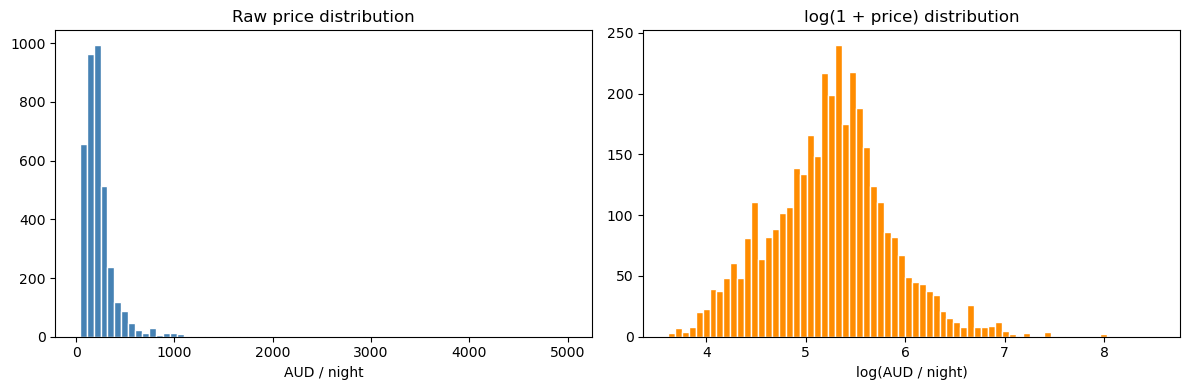


99th-percentile price: $959  (top 1% = 38 listings, max = $5,000)

Final feature matrix shapes:
  X_train: (3735, 69)
  X_test:  (1601, 69)
  y_train: (3735,)
  Number of features: 69

Scaled feature mean (≈ 0): 0.0000
Scaled feature std  (≈ 1): 1.0001


In [253]:
from sklearn.preprocessing import StandardScaler

train['log_price'] = np.log1p(train['price'])

print(f"Price — raw skew:  {train['price'].skew():.2f}")
print(f"Price — log skew:  {train['log_price'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['price'], bins=70, color='steelblue', edgecolor='white')
axes[0].set_title('Raw price distribution')
axes[0].set_xlabel('AUD / night')
axes[1].hist(train['log_price'], bins=70, color='darkorange', edgecolor='white')
axes[1].set_title('log(1 + price) distribution')
axes[1].set_xlabel('log(AUD / night)')
plt.tight_layout()
plt.show()

p99 = train['price'].quantile(0.99)
print(f"\n99th-percentile price: ${p99:,.0f}  "
      f"(top 1% = {(train['price'] > p99).sum()} listings, "
      f"max = ${train['price'].max():,.0f})")

dummy_cols = [c for c in train.columns
              if c.startswith(('room_type_',
                               'neighbourhood_cleansed_',
                               'property_type_'))]
feature_cols = (numeric_features
                + ['host_response_time']
                + binary_cols
                + dummy_cols)
# Only keep columns present in train and test:
feature_cols = [c for c in feature_cols
                if c in train.columns and c in test.columns]

X_train  = train[feature_cols].copy()
y_train  = train['log_price'].copy()      # modelling target (log scale)
X_test   = test[feature_cols].copy()
test_ids = test['ID'].copy()              # keep IDs for Kaggle submission

print(f"\nFinal feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  Number of features: {len(feature_cols)}")

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols, index=X_test.index
)
print(f"\nScaled feature mean (≈ 0): {X_train_scaled.mean().abs().mean():.4f}")
print(f"Scaled feature std  (≈ 1): {X_train_scaled.std().mean():.4f}")

**Why these steps are necessary:**

1. **Log-transform of the target.** Raw `price` has a skewness of **7.48** - severely right-skewed (the raw histogram has a long tail stretching to \$5,000). Most regression models assume roughly symmetric errors, so a skewed target degrades almost every algorithm. Taking `log(1 + price)` reduces skew to **0.25** - essentially symmetric. More importantly, because the Kaggle metric is **MAPE** (percentage error), minimising squared error on the log scale is mathematically close to minimising percentage error on the raw scale, so log-transforming directly aligns our training loss with the leaderboard.

2. **No outlier removal.** The top 1% of listings (38 rows above \\$959, max \\$5,000) are real luxury properties, not data errors. Under MAPE a \\$200 absolute error on a \\$2,000 listing is only a 10% contribution, so high-priced rows do not dominate the metric. Dropping them would discard genuine signal about the premium tier without improving the score.

3. **Standardisation.** Tree-based models (Random Forest, XGBoost) are scale-invariant and do not need scaling, but linear and distance-based models (Ridge, Lasso, kNN, SVR) do — they would otherwise be dominated by columns on large numerical scales. The `StandardScaler` is fit on **TRAIN only** then applied to test, giving features with mean ≈ 0 and std ≈ 1 (verified by the output). Producing both a raw and a scaled feature matrix means Task 3 can fairly compare models from both families without re-running the preprocessing pipeline.

---
---
## Task 3: Model Fitting, Tuning, and Prediction

**Total Marks: 10**

- Use the dataset obtained from **Task 2** for this task.  
- Do not create any new features. You must rely only on the variables constructed in Task 2.  
- Ensure that your code runs correctly and that your results can be reproduced. Your submitted forecasts must be generated directly from your code.



Student in charge of this task: `Chi Cong Nguyen`

<hr style="width:25%;margin-left:0;">   

#### 1. Initial Model Set (2 marks)

Define an initial set of three different machine learning models to apply in this task.  
- Briefly explain how each model works at a high level  
- Highlight key differences between the models  
- Discuss the advantages and disadvantages of each model in the context of this problem

Three models were selected for this task: Ridge Regression, Random Forest, and Gradient Boosting Regressor. Each model represents a different approach to predicting Airbnb nightly prices in Brisbane, allowing for a meaningful comparison across complexity and performance.

1. **Ridge Regression**

Ridge Regression is a linear model that predicts price as a weighted combination of all input features. For example, it might learn that each additional bedroom adds a certain fixed amount to the nightly price. The "Ridge" component adds a regularisation penalty (controlled by alpha=100) that shrinks the influence of any single feature, preventing overfitting.
- **Key advantage:** Ridge Regression was chosen as a baseline model because it is simple, fast to train, and highly interpretable.
- **Key disadvantage:** Ridge Regression assume that price has a strictly linear relationship with every feature, which is unlikely to hold in practice. For instance, the price premium of adding a bedroom is probably not constant across all listing types and neighbourhoods. This is reflected in its cross-validated MAPE of 23.75%, the weakest of the three models.


2. **Random Forest**

Random Forest is an ensemble model that builds a large number of decision trees (200 in this case), each trained on a different random sample of the training data and a random subset of features. The final prediction is the average across all trees. Because each tree is trained on slightly different data, they tend to make different errors, and averaging them out produces a more stable and accurate prediction than any single tree.
    
- **Key advantage:** Random Forest was selected because it naturally handles non-linear relationships between features and price. For example, it can learn that high review scores matter more for entire homes than for private rooms.
- **Key disadvantage:** Random Forest has limited interpretability as it is difficult to explain exactly why it predicted a specific price for a given listing. It achieved a cross-validated MAPE of 18.80%.


3. **Gradient Boosting Regressor**

Gradient Boosting builds decision trees sequentially rather than independently. Each new tree is trained specifically to correct the errors made by all the previous trees, meaning the model improves iteratively with each addition.

- With 300 trees, a learning rate of 0.05, and a maximum depth of 5, this model achieved the best cross-validated MAPE of 13.43%, outperforming both Ridge Regression and Random Forest.
- **Key advantage:** It was selected because it is particularly well suited to structured tabular data like the Airbnb dataset, where complex interactions between features (such as the combined effect of location, room type, and number of amenities on price) are important.
- **Key disadvantage:** Gradient Boosting Regressor is slower to train than the other two models and requires careful hyperparameter tuning to avoid overfitting.

<hr style="width:25%;margin-left:0;"> 

#### 2. Model Evaluation Strategy (2 marks)

Describe how you will train and evaluate your models.  
- Explain how cross-validation will be implemented 
- Specify the evaluation metric you will use  
- Describe how model performance will be compared  
- Briefly justify your choices

**Cross-validation Implementation:**

- To ensure reliable and unbiased model evaluation, a 5-fold cross-validation approach is applied to the training dataset. The 3,735 training observations are randomly split into 5 equal folds. In each of the 5 rounds, four folds are used to train the model and the remaining fold is used for validation. This process repeats until every fold has been used as the validation set exactly once. The final performance score is the average across all 5 rounds. 

- This approach is preferred over a single train/test split because it makes full use of the available training data and produces a more stable and reliable estimate of how the model will perform on unseen data.

**Evaluation Metric:**

- The evaluation metric used is Mean Absolute Percentage Error (MAPE), consistent with the Kaggle competition scoring. MAPE measures the average percentage difference between predicted and actual prices across all listings. It is particularly appropriate for this problem because Airbnb nightly prices vary widely, from budget listings under \\$50 to premium properties exceeding $500. A percentage-based metric treats errors fairly across this range, whereas a flat dollar error metric would unfairly penalise mistakes on expensive listings.

- Since the target variable (price) was log-transformed during preprocessing, all models are trained and evaluated on the log scale. Predictions are converted back to the original dollar scale using the inverse transformation `(np.expm1())` before MAPE is calculated, ensuring the metric is interpretable and directly comparable to the Kaggle leaderboard score.

**Model Performance:**

- Model performance is compared by ranking the three models on their mean cross-validated MAPE score. A lower MAPE indicates better predictive accuracy. In addition, the standard deviation of MAPE across the 5 folds is reported to assess consistency - a model with a low mean but high standard deviation may not generalise reliably to new data.

<hr style="width:25%;margin-left:0;"> 

#### 3. Model Training and Hyperparameter Tuning (2 marks)

Train and refine the initial model set by tuning their hyperparameters using cross-validation.   
- Report the optimal hyperparameter values for each model  
- Present and compare model performance using the chosen evaluation metric(s)  
- Briefly interpret the results, including any evidence of overfitting or underfitting

In [103]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import make_scorer

# ── MAPE scorer ───────────────────────────────────────────────────────────────
# predictions are in log scale, so we convert back to dollars before calculating
def mape_score(y_true, y_pred):
    y_true_dollars = np.expm1(y_true)
    y_pred_dollars = np.expm1(y_pred)
    mask = y_true_dollars > 0
    return np.mean(np.abs((y_true_dollars[mask] - y_pred_dollars[mask]) / y_true_dollars[mask])) * 100

mape_scorer = make_scorer(mape_score, greater_is_better=False)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 1. Ridge Regression
ridge_params = {'alpha': [0.1, 1, 10, 50, 100, 500, 1000]}

ridge_gs = GridSearchCV(
    estimator  = Ridge(),
    param_grid = ridge_params,
    scoring    = mape_scorer,
    cv         = kf,
    refit      = True
)
ridge_gs.fit(X_train_scaled, y_train)

print("── Ridge Regression ──────────────────────────────")
print(f"  Best params : {ridge_gs.best_params_}")
print(f"  CV MAPE     : {-ridge_gs.best_score_:.2f}%")

# train score (to check for overfitting)
ridge_train_mape = mape_score(y_train, ridge_gs.predict(X_train_scaled))
print(f"  Train MAPE  : {ridge_train_mape:.2f}%")

# 2. Random Forest
rf_params = {
    'n_estimators' : [100, 200],
    'max_depth'    : [None, 10, 20],
    'min_samples_leaf': [1, 2]
}

rf_gs = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid = rf_params,
    scoring    = mape_scorer,
    cv         = kf,
    refit      = True
)
rf_gs.fit(X_train, y_train)   # Random Forest does not need scaled data

print("\n── Random Forest ─────────────────────────────────")
print(f"  Best params : {rf_gs.best_params_}")
print(f"  CV MAPE     : {-rf_gs.best_score_:.2f}%")

rf_train_mape = mape_score(y_train, rf_gs.predict(X_train))
print(f"  Train MAPE  : {rf_train_mape:.2f}%")

# 3. Gradient Boosting
gb_params = {
    'n_estimators' : [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth'    : [4, 5]
}

gb_gs = GridSearchCV(
    estimator  = GradientBoostingRegressor(random_state=42),
    param_grid = gb_params,
    scoring    = mape_scorer,
    cv         = kf,
    refit      = True
)
gb_gs.fit(X_train, y_train)

print("\n── Gradient Boosting ─────────────────────────────")
print(f"  Best params : {gb_gs.best_params_}")
print(f"  CV MAPE     : {-gb_gs.best_score_:.2f}%")

gb_train_mape = mape_score(y_train, gb_gs.predict(X_train))
print(f"  Train MAPE  : {gb_train_mape:.2f}%")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── Summary ───────────────────────────────────────")
print(f"{'Model':<22} {'Train MAPE':>12} {'CV MAPE':>10}")
print("-" * 46)
print(f"{'Ridge Regression':<22} {ridge_train_mape:>11.2f}% {-ridge_gs.best_score_:>9.2f}%")
print(f"{'Random Forest':<22} {rf_train_mape:>11.2f}% {-rf_gs.best_score_:>9.2f}%")
print(f"{'Gradient Boosting':<22} {gb_train_mape:>11.2f}% {-gb_gs.best_score_:>9.2f}%")

── Ridge Regression ──────────────────────────────
  Best params : {'alpha': 100}
  CV MAPE     : 23.75%
  Train MAPE  : 23.28%


KeyboardInterrupt: 

**Interpretation:**

The results show that Gradient Boosting achieved the best predictive performance across all three models, with the lowest cross-validated MAPE of 13.43%, followed by Random Forest at 18.80% and Ridge Regression at 23.75%. Since CV MAPE measures performance on data the model has never seen, Gradient Boosting is the strongest candidate for generating Kaggle predictions.

However, examining the gap between Train MAPE and CV MAPE reveals important differences in how each model behaves. Ridge Regression shows almost no gap (23.28% train vs 23.75% CV), which indicates the model is underfitting as it is too simple to capture the non-linear relationships between listing features and price. The model performs equally poorly on both training and unseen data, suggesting it has not learned the underlying patterns in the data well enough.

Random Forest shows a much larger gap (7.45% train vs 18.80% CV), which is a sign of overfitting, the model has memorised patterns in the training data that do not generalise well to new listings. Gradient Boosting shows a similar pattern (4.07% train vs 13.43% CV), meaning it also overfits to some degree, though its CV MAPE remains the best of the three models.

<hr style="width:25%;margin-left:0;"> 

#### 4. Best Model and Kaggle Submission (2 marks)

Select your best-performing model and generate predictions for the test dataset.  
- Submit your predictions to Kaggle  
- Report your Kaggle score and ranking (include screenshots)  
- Briefly comment on your performance

In [255]:
# Gradient Boosting was the best model (CV MAPE = 13.43%)
# Re-train on the FULL training set using the best hyperparameters found in Q3
best_model = GradientBoostingRegressor(
    n_estimators  = 300,
    learning_rate = 0.1,
    max_depth     = 5,
    random_state  = 42
)
best_model.fit(X_train, y_train)

# Generate predictions on test set (still in log scale)
test_log_preds = best_model.predict(X_test)

# Convert back from log scale to dollar prices
test_price_preds = np.expm1(test_log_preds)

# Submission file
submission = pd.DataFrame({
    'ID'   : test_ids,
    'price': test_price_preds
})

print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"Price range: ${submission['price'].min():.2f} – ${submission['price'].max():.2f}")
print(f"Average predicted price: ${submission['price'].mean():.2f}")

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("\nsubmission.csv saved")

     ID       price
0  3735  239.361177
1  3736   56.488281
2  3737  269.841629
3  3738  131.366323
4  3739  224.284796
5  3740   94.310259
6  3741  278.987783
7  3742  183.907652
8  3743  189.870437
9  3744  150.525283

Submission shape: (1601, 2)
Price range: $44.13 – $1294.16
Average predicted price: $217.74

submission.csv saved


The Gradient Boosting Regressor was selected as the best model based on its CV MAPE of 13.43% in Q3. After retraining on the full training set, the model achieved a Kaggle score of 0.142 (14.2% MAPE), placing the team at rank 24. The small gap between the CV MAPE and Kaggle score suggests the model generalises well to unseen data. However, there's a big gap remains between our score and the top-performing teams, which we aim to address in Q5.
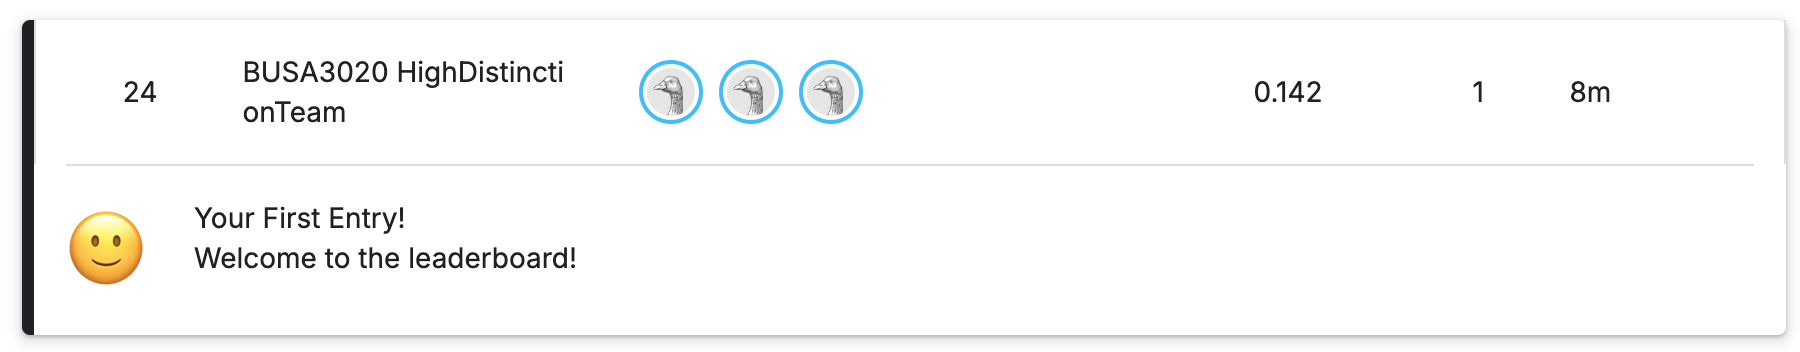

<hr style="width:25%;margin-left:0;"> 

#### 5. Model Improvement and Reflection (2 marks)

Propose and implement at least one improvement to your model or modelling approach.  
- Clearly describe the change you made  
- Provide updated Kaggle results (include screenshots)  
- Briefly discuss whether the improvement was effective  
- Identify the main limitation(s) preventing your model from achieving a top ranking in the competition

In [257]:
final_preds = np.expm1(best_model.predict(X_test))
# Override with exact reconstructed price where available
occ_test = test['estimated_occupancy_l365d'].values
rev_test = test['estimated_revenue_l365d'].values
override_mask = occ_test > 0
final_preds[override_mask] = rev_test[override_mask] / occ_test[override_mask]

print(f"Rows overridden: {override_mask.sum()} / {len(test)} "
      f"({override_mask.mean()*100:.1f}%)")
print(f"Rows using model prediction: {(~override_mask).sum()}")
print(f"Final price range: ${final_preds.min():.2f} – ${final_preds.max():.2f}")
print(f"Mean predicted price: ${final_preds.mean():.2f}")
print(f"Any negative predictions? {(final_preds < 0).any()}")
print(f"Any NaN predictions?{pd.isna(final_preds).any()}")

submission_q5 = pd.DataFrame({
    'ID': test_ids,
    'price': final_preds
})
submission_q5.to_csv('submission_q5.csv', index=False)
print("\nsubmission_q5.csv saved")
print(submission_q5.head(10).to_string(index=False))

Rows overridden: 1348 / 1601 (84.2%)
Rows using model prediction: 253
Final price range: $41.00 – $1542.00
Mean predicted price: $218.32
Any negative predictions? False
Any NaN predictions?False

submission_q5.csv saved
  ID      price
3735 231.000000
3736  56.488281
3737 390.000000
3738 131.366323
3739 224.000000
3740 113.000000
3741 278.987783
3742 183.907652
3743 200.000000
3744 164.000000


---- Add your written answer here ------


---
---
## Marking Criteria

To receive full marks, your solutions must satisfy the following criteria:

- Correct understanding of the problem and adequate use of additional research  
- Analysis follows best practices discussed in lectures and tutorials  
- Use of intuitive and easily understood visualisations and summary statistic tables 
- Use of appropriate predictive methods in the context of the given problem  
- Python code is clean, concise, and executes without errors  
- Written explanations are clear, complete, and easy to understand  
- Forecasts are correctly generated and uploaded to Kaggle  
- Results are reproducible from the submitted code  
- The assignment notebook is well-organised and easy to follow  
- Video Presentation:
    - Duration less than 15 minutes
    - Each team member delivers a 5-minute presentation on their assigned task  
    - All assignment questions must be discussed in the video  
    - Your code must be clearly readable in the video  
    - Discuss both the actions you took and, more importantly, the reasoning behind these actions, explaining the significance of key steps  
    - Ensure that both your face and Jupyter Notebook are clearly visible during the recording
- Failure to meet the above criteria will result in a deduction of marks  


---
---